# Feature Engineering and Polynomial Regression

## Goals
Explore how feature engineering lets linear regression fit curves and non-linear patterns, not just straight lines.

In [4]:
import numpy as np 
import matplotlib.pyplot as plt
np.set_printoptions(precision=2)
import copy

## Setup
Reusing compute_cost, compute_gradient, and gradient_descent from previous labs, wrapped in a helper that also prints the final w, b.

In [20]:
#cost_funtion
def compute_cost(x,y,w,b):
    m = x.shape[0]
    cost = 0.0
    for i in range(m):
        f_wb_i = np.dot(x[i],w)+b
        cost += (f_wb_i-y[i])**2
    cost = cost/(2*m)
    return cost

#gradient_compute_fucntion
def compute_gradient(x,y,w,b):
    m,n = x.shape
    dj_dw = np.zeros(n,)
    dj_db = 0.0
    for i in range(m):
        err = (np.dot(x[i],w)+b)-y[i]
        for j in range(n):
            dj_dw+= err*x[j]
        dj_db += err
    dj_dw = dj_dw/m
    dj_db = dj_db/m
    return dj_dw,dj_db

#gradient_descent
def gradient_descent(x,y,w_in,b_in,cost_function,gradient_function,alpha,num_iters):
    j_history = []
    w = copy.deepcopy(w_in)
    b = b_in

    for i in range(num_iters):
        dj_dw,dj_db = gradient_function(x,y,w,b)
        w = w-alpha*dj_dw
        b = b-alpha*dj_db
        if i<100000:
            j_history.append(cost_function(x,y,w,b))
        if i%max(1,num_iters//10)==0:
             print(f"Iteration {i:4d}: Cost {j_history[-1]:8.2f}")
    return w, b, j_history

In [21]:
def run_gradient_descent(X, y, iterations=1000, alpha=1e-6):
    m, n = X.shape
    initial_w = np.zeros(n)
    initial_b = 0.
    w_out, b_out, hist = gradient_descent(X, y, initial_w, initial_b,
                                           compute_cost, compute_gradient,
                                           alpha, iterations)
    print(f"w,b found by gradient descent: w: {w_out}, b: {b_out:0.4f}")
    return w_out, b_out

## Polynomial Features

Let's try fitting a simple curve: y = 1 + x^2, using plain linear regression first, with no engineering.

Iteration    0: Cost 14036.42
Iteration  100: Cost  7458.22
Iteration  200: Cost  6576.88
Iteration  300: Cost  6458.79
Iteration  400: Cost  6442.97
Iteration  500: Cost  6440.85
Iteration  600: Cost  6440.57
Iteration  700: Cost  6440.53
Iteration  800: Cost  6440.53
Iteration  900: Cost  6440.53
w,b found by gradient descent: w: [0.], b: 124.4946


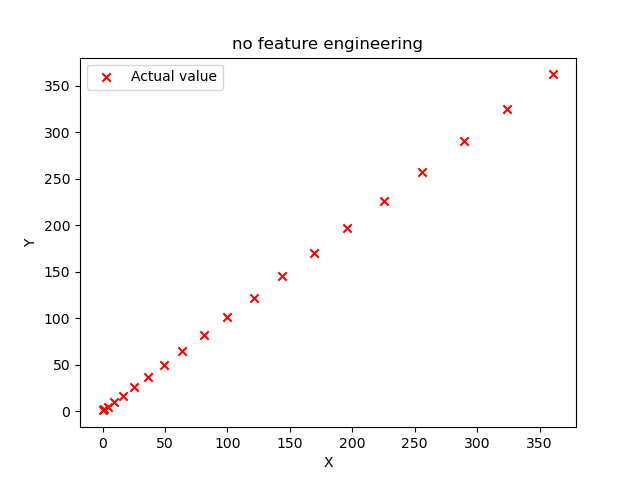

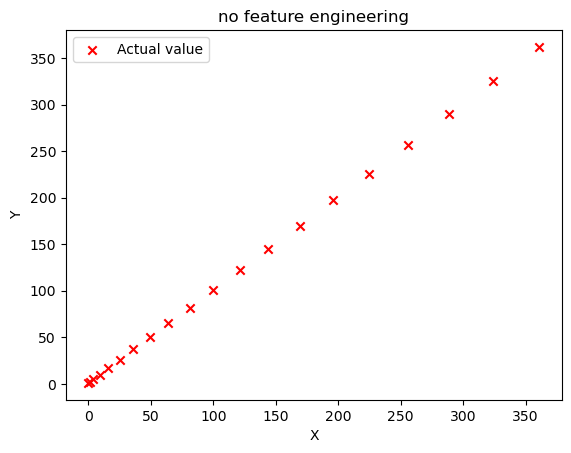

In [29]:
x = np.arange(0,20,1)
y = 1+x**2
#conversion into matrix
x = x**2
X = x.reshape(-1,1)

model_w, model_b = run_gradient_descent(X, y, iterations=1000, alpha=1e-2)
plt.scatter(x,y, marker='x',c='red',label = 'Actual value')
plt.title("no feature engineering")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.savefig("no_features_eng.png")
plt.close

from IPython.display import Image
Image("no_features_eng.png")

Not a great fit. What's actually needed is something like y = w0*x0^2 + b - a polynomial feature. We can engineer this by feeding the model x-squared as the input instead of x.

Iteration    0: Cost 14190.49
Iteration 1000: Cost 14037.03
Iteration 2000: Cost 13886.61
Iteration 3000: Cost 13739.17
Iteration 4000: Cost 13594.65
Iteration 5000: Cost 13452.98
Iteration 6000: Cost 13314.13
Iteration 7000: Cost 13178.02
Iteration 8000: Cost 13044.61
Iteration 9000: Cost 12913.84
w,b found by gradient descent: w: [0.], b: 11.8478


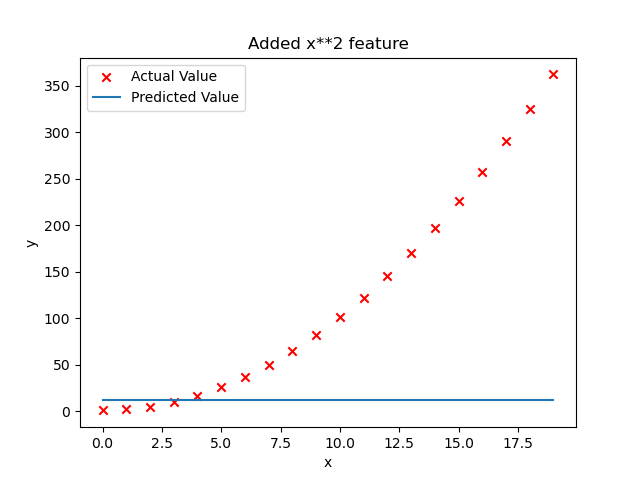

In [26]:
x = np.arange(0, 20, 1)
y = 1 + x**2

X = x**2
X = X.reshape(-1, 1)

model_w, model_b = run_gradient_descent(X, y, iterations=10000, alpha=1e-5)

plt.scatter(x, y, marker='x', c='red', label='Actual Value')
plt.title("Added x**2 feature")
plt.plot(x, X@model_w + model_b, label="Predicted Value")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.savefig("x_squared_feature.png")
plt.close()

from IPython.display import Image
Image("x_squared_feature.png")

### Selecting Features
We knew x^2 was needed here, but it's not always obvious which power is right. Let's give the model several options (x, x^2, x^3) and see which one gradient descent actually emphasizes.

Iteration    0: Cost 14014.14
Iteration 1000: Cost   435.46
Iteration 2000: Cost   488.92
Iteration 3000: Cost   585.74
Iteration 4000: Cost   606.55
Iteration 5000: Cost   610.49
Iteration 6000: Cost   611.22
Iteration 7000: Cost   611.36
Iteration 8000: Cost   611.38
Iteration 9000: Cost   611.39
w,b found by gradient descent: w: [0.02 0.04 0.07], b: 0.0073


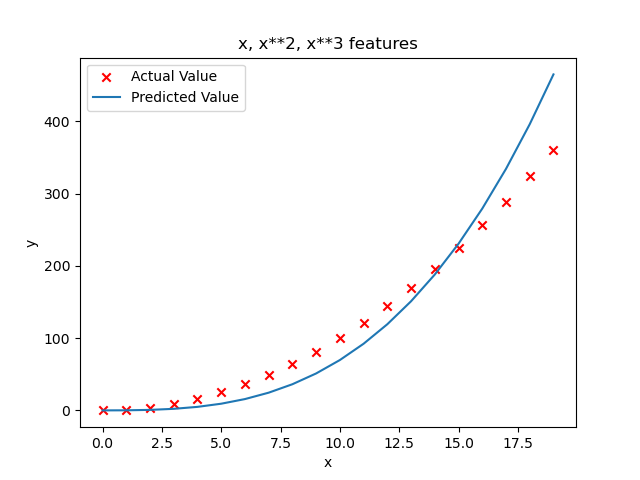

In [27]:
x = np.arange(0, 20, 1)
y = x**2

#making columns
X = np.c_[x, x**2, x**3]

model_w, model_b = run_gradient_descent(X, y, iterations=10000, alpha=1e-7)

plt.scatter(x, y, marker='x', c='red', label='Actual Value')
plt.title("x, x**2, x**3 features")
plt.plot(x, X@model_w + model_b, label="Predicted Value")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.savefig("multi_poly_features.png")
plt.close()

from IPython.display import Image
Image("multi_poly_features.png")

### An Alternate View
Since we're still doing linear regression under the hood, the best engineered feature will be the one that looks linear when plotted against the target y. Let's check.

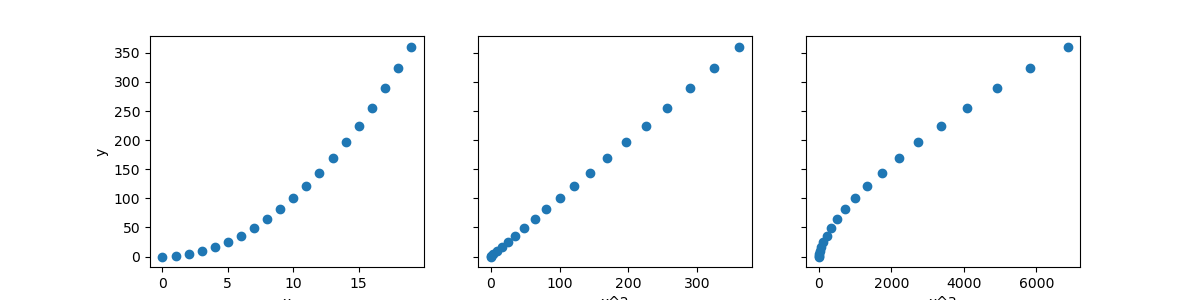

In [28]:
x = np.arange(0, 20, 1)
y = x**2

X = np.c_[x, x**2, x**3]
X_features = ['x', 'x^2', 'x^3']

fig, ax = plt.subplots(1, 3, figsize=(12, 3), sharey=True)
for i in range(len(ax)):
    ax[i].scatter(X[:, i], y)
    ax[i].set_xlabel(X_features[i])
ax[0].set_ylabel("y")
plt.savefig("feature_linearity_check.png")
plt.close()

from IPython.display import Image
Image("feature_linearity_check.png")

### Scaling features
Just like in the previous lab, features with very different scales (x vs x^2 vs x^3) slow down gradient descent. Let's apply z-score normalization here too.

In [30]:
def zscore_normalize_features(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

In [31]:
x = np.arange(0, 20, 1)
X = np.c_[x, x**2, x**3]
print(f"Peak to Peak range by column in Raw X: {np.ptp(X, axis=0)}")

X_norm, X_mu, X_sigma = zscore_normalize_features(X)
#calculating peal to peak max-min
print(f"Peak to Peak range by column in Normalized X: {np.ptp(X_norm, axis=0)}")

Peak to Peak range by column in Raw X: [  19  361 6859]
Peak to Peak range by column in Normalized X: [3.3  3.18 3.28]


Now let's try again with a much bigger alpha, using the normalized features.

Iteration    0: Cost 34424.91
Iteration 10000: Cost 920598.22
Iteration 20000: Cost 920598.22
Iteration 30000: Cost 920598.22
Iteration 40000: Cost 920598.22
Iteration 50000: Cost 920598.22
Iteration 60000: Cost 920598.22
Iteration 70000: Cost 920598.22
Iteration 80000: Cost 920598.22
Iteration 90000: Cost 920598.22
w,b found by gradient descent: w: [-546.15 -397.72 -319.57], b: 123.5000


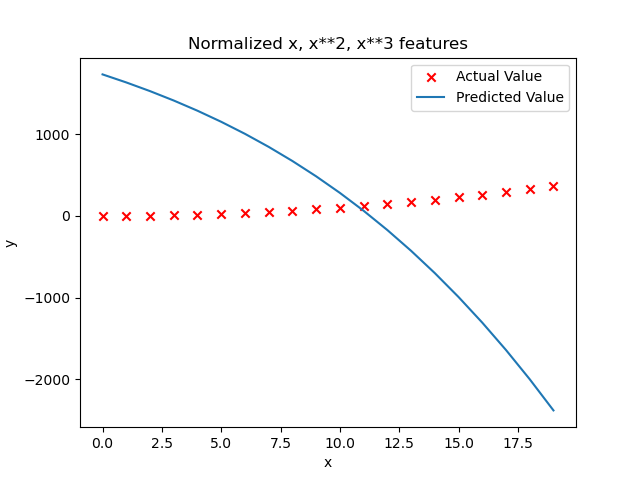

In [33]:
x = np.arange(0, 20, 1)
y = x**2

X = np.c_[x, x**2, x**3]
X_norm, X_mu, X_sigma = zscore_normalize_features(X)

model_w, model_b = run_gradient_descent(X_norm, y, iterations=100000, alpha=1e-1)

plt.scatter(x, y, marker='x', c='red', label='Actual Value')
plt.title("Normalized x, x**2, x**3 features")
#actually doing regression
plt.plot(x, X_norm@model_w + model_b, label="Predicted Value")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.savefig("normalized_poly.png")
plt.close()

from IPython.display import Image
Image("normalized_poly.png")


### Complex Functions
With enough engineered features, even a wavy, non-polynomial-looking function can be fit.

In [ ]:
x = np.arange(0, 20, 1)
y = np.cos(x/2)

X = np.c_[x, x**2, x**3, x**4, x**5, x**6, x**7, x**8, x**9, x**10, x**11, x**12, x**13]
X_norm, X_mu, X_sigma = zscore_normalize_features(X)

model_w, model_b = run_gradient_descent(X_norm, y, iterations=100000, alpha=1e-1)

plt.scatter(x, y, marker='x', c='red', label='Actual Value')
plt.title("Normalized x, x**2, ..., x**13 features")
plt.plot(x, X_norm@model_w + model_b, label="Predicted Value")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.savefig("cosine_fit.png")
plt.close()

from IPython.display import Image
Image("cosine_fit.png")

## Summary
Learned that linear regression can fit non-linear curves by engineering polynomial features (x^2, x^3, etc.) rather than changing the model itself. Gradient descent naturally emphasizes the most useful engineered features. Feature scaling remains essential once multiple engineered features are combined, since their raw scales differ drastically.